# Preparation

In [1]:
from matplotlib.ticker import MaxNLocator, AutoMinorLocator
import numpy as np

In [2]:
def COLORS():
    return {
    "red":   "#D17477",  # red
    "yellow":"#FFDD11",  # yellow
    "blue":  "#5289bb",  # blue
    "green": "#78bb75",  # green
}

def plot_loss(loss_list, save_path='results/result.pdf', figsize=(7, 4), color = COLORS()['red'], show_plot=True, xlabel='Iteration', ylabel='Loss', title='Training Loss over Time'):
    steps = np.arange(1, len(loss_list) + 1)
    save_dir = os.path.dirname(save_path)
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    plt.figure(figsize=figsize)
    plt.plot(steps, loss_list, color=color, label='Training Loss', linewidth=1.5)

    ax = plt.gca()
    for s in ["top", "right", "bottom", "left"]:
        ax.spines[s].set_visible(True)
    ax.tick_params(axis="both", which="both",
                top=True, right=True, bottom=True, left=True,
                labeltop=False, labelright=False,
                direction="in")
    # 主刻度设置
    ax.xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))  # epoch 通常用整数
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    # 次刻度设置
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    ticks = list(ax.get_xticks())
    if 1 not in ticks:
        ticks.append(1)
    if steps[-1] not in ticks:
        ticks.append(steps[-1])
    ticks = sorted(set(int(t) for t in ticks if t >= steps[0]))  # 去掉 <1 的，确保整数
    ax.set_xticks(ticks)

    # 网格（主/次都画一点，便于读数）
    ax.grid(True, which="major", linestyle="--", linewidth=0.8, alpha=0.35)
    ax.grid(True, which="minor", linestyle="--", linewidth=0.5, alpha=0.18)

    ax.set_xlim(left=steps[0], right=steps[-1])  # left=1, right=max step
    ax.margins(x=0)             # 去掉默认留白

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, transparent=True)
    if show_plot:
        plt.show()

# Target test

In [3]:
from transformers import GPT2LMHeadModel

/home/fcr/miniconda3/envs/llm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 查看模型组件、参数大小

In [4]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2") # 124M, 加载模型
# gpt2 = GPT2LMHeadModel.from_pretrained("gpt2-xl") # 1.5B

# print the model's state dict keys and their shapes
sd_hf = model_hf.state_dict() # state_dict: Dict[str (参数名), Tensor (参数值)]

for k, v in sd_hf.items():
    print(k, v.shape)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1038.45it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

## 可视化

In [5]:
# 随机查看某部分的weight的前20个
sd_hf["transformer.wte.weight"].view(-1)[0:20]

tensor([-0.1101, -0.0393,  0.0331,  0.1338, -0.0485, -0.0789, -0.2398, -0.0895,
         0.0253, -0.1074, -0.1811, -0.0672,  0.0739, -0.0161,  0.0117,  0.1245,
        -0.0020, -0.0815,  0.0338,  0.2365])

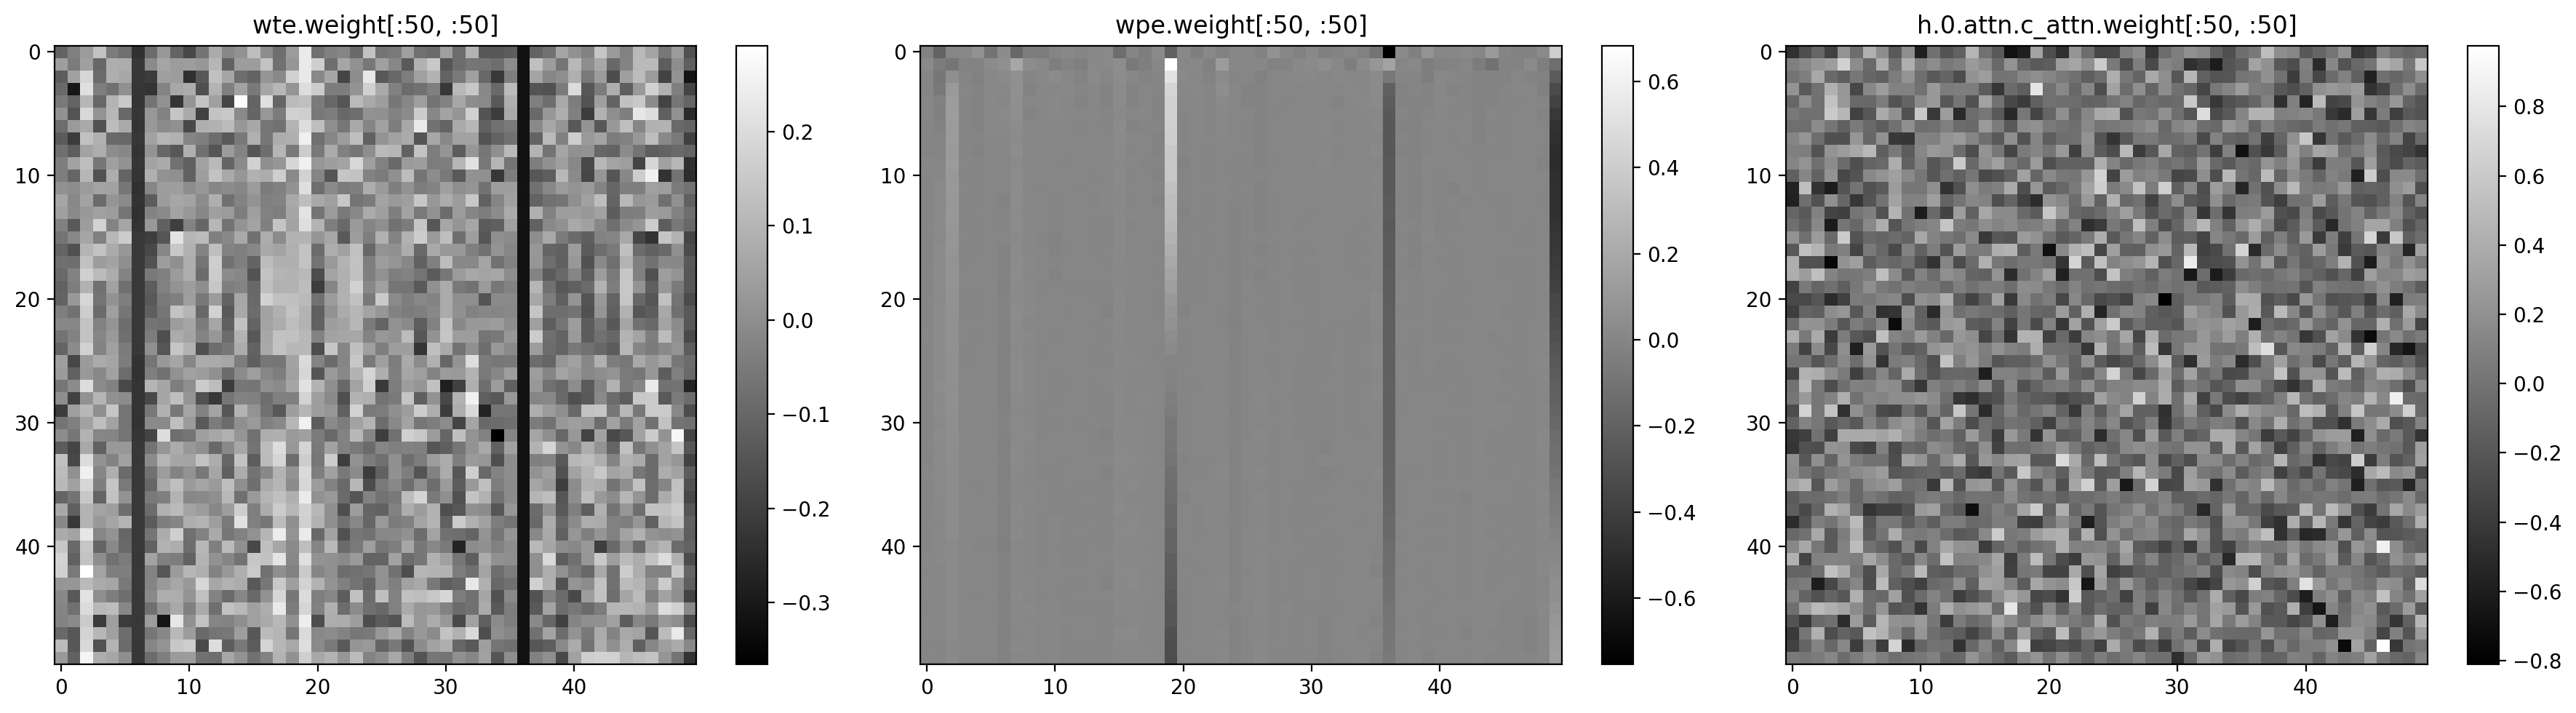

In [6]:
from matplotlib import pyplot as plt

plt.figure(figsize=(18, 5), dpi=200)
plt.subplot(1, 3, 1)
plt.imshow(sd_hf["transformer.wte.weight"][:50, :50], aspect="auto", cmap="gray")
plt.title("wte.weight[:50, :50]")
plt.colorbar()
plt.subplot(1, 3, 2)
plt.imshow(sd_hf["transformer.wpe.weight"][:50, :50], aspect="auto", cmap="gray")
plt.title("wpe.weight[:50, :50]")
plt.colorbar()
plt.subplot(1, 3, 3)
plt.imshow(sd_hf["transformer.h.0.attn.c_attn.weight"][:50, :50], aspect="auto", cmap="gray")
plt.title("h.0.attn.c_attn.weight[:50, :50]")
plt.colorbar()
plt.tight_layout()
plt.savefig("outputs/param_heatmaps.pdf", transparent=True)
plt.show()

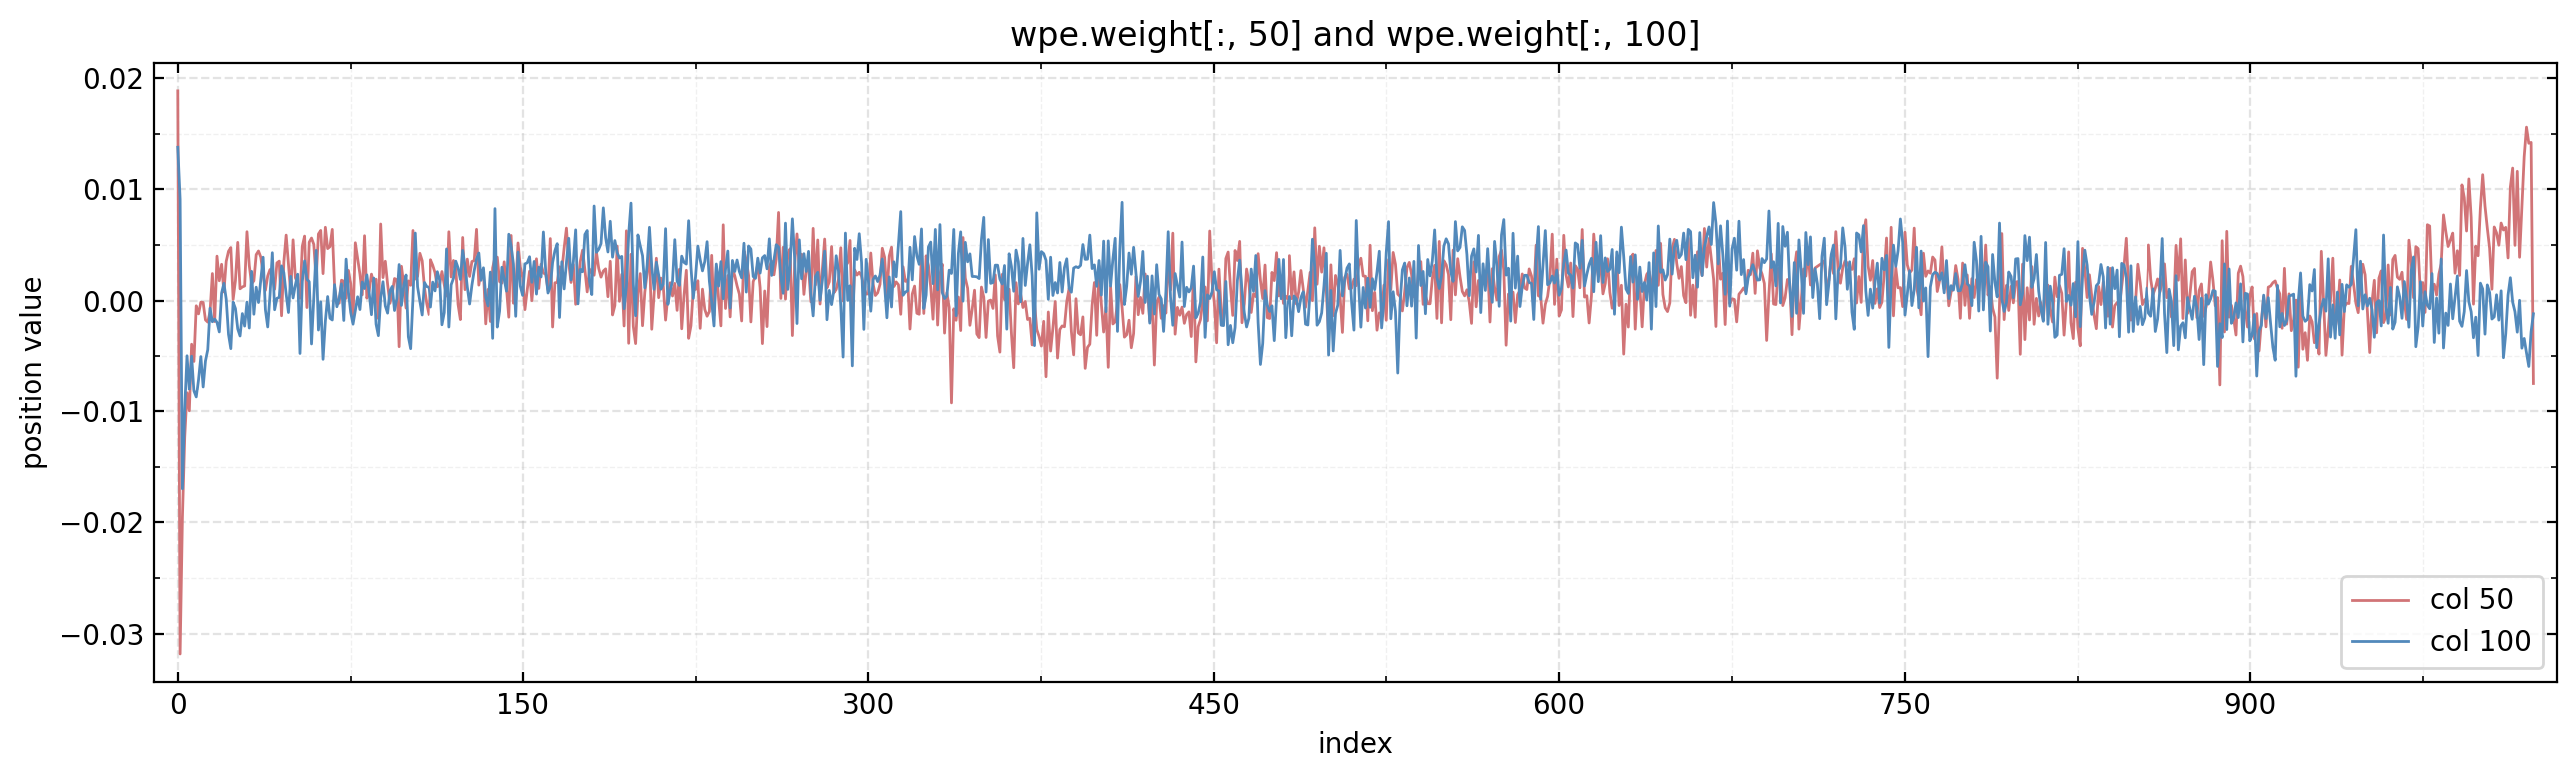

In [7]:
# 查看 wpe.weight 的某些列
plt.figure(figsize=(13, 4), dpi=200)
plt.plot(sd_hf["transformer.wpe.weight"][:, 50], label="col 50", linewidth=1, color=COLORS()['red'])
plt.plot(sd_hf["transformer.wpe.weight"][:, 100], label="col 100", linewidth=1, color=COLORS()['blue'])
plt.xlabel("index")
plt.ylabel("position value")
plt.legend()
ax = plt.gca()
for s in ["top", "right", "bottom", "left"]:
    ax.spines[s].set_visible(True)
ax.tick_params(axis="both", which="both",
            top=True, right=True, bottom=True, left=True,
            labeltop=False, labelright=False,
            direction="in")
# 主刻度设置
ax.xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))  # epoch 通常用整数
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
# 次刻度设置
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

ticks = list(ax.get_xticks())
ax.set_xticks(ticks)

# 网格（主/次都画一点，便于读数）
ax.grid(True, which="major", linestyle="--", linewidth=0.8, alpha=0.35)
ax.grid(True, which="minor", linestyle="--", linewidth=0.5, alpha=0.18)

ax.margins(x=0.01)             # 去掉默认留白
plt.title("wpe.weight[:, 50] and wpe.weight[:, 100]")
plt.tight_layout()
plt.savefig("outputs/wpe_weight_cols.pdf", transparent=True)
plt.show()

- 可以看出上面的 embedding 是很 noisy 的，说明模型暂时是并没有得到很好的训练。预期来说，一个得到很好训练的模型应该是光滑的曲线.
- 在 *Attention is all you need* 原文中，positional embedding 是由 sin cos 函数固定的，但在 GPT-2 中这部分也是可以训练的.

## 生成内容测试

In [8]:
from transformers import pipeline, set_seed
generator = pipeline("text-generation", model='gpt2')
set_seed(11)
generator(
    "Hi, I am a Chatbot,",
    max_length=10,
    num_return_sequences=2
)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1159.38it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=10) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "Hi, I am a Chatbot, and you know my name, Nicky! I do a lot of Chatbot stuff for you guys at Chatbot.com, and I'm always looking to help you, so please, consider helping me out with whatever I can!\n\nDonate to the Chatbot Foundation!"},
 {'generated_text': 'Hi, I am a Chatbot, and an author. I am an atheist. I am a big fan of The Bible. I am a big fan of the Bible. And I am a big fan of The Bible.\n\nI\'m not going to lie, I\'m not going to lie. I am a big fan of The Bible. And I am a big fan of The Bible. And I\'m a big fan of The Bible.\n\nPeople say, "Well, you\'re a big fan of The Bible!" But I\'m not going to say that. I\'m not going to say that.\n\nPeople say, "Well, you\'re a big fan of The Bible." But I\'m not going to say that. I\'m not going to say that.\n\nPeople say, "Well, you\'re a big fan of The Bible!" But I\'m not going to say that. I\'m not going to say that.\n\nPeople say, "Well, you\'re a big fan of The Bible!" But I\'m not going to say that. I

- pipeline = tokenizer + model + decoding

# Bug fixed

## Note 1: lm_head.weight == transformer.wte.weight

In [10]:
print(sd_hf["transformer.wte.weight"].shape)
print(sd_hf["lm_head.weight"].shape)

torch.Size([50257, 768])
torch.Size([50257, 768])


In [ ]:
print(sd_hf["transformer.wte.weight"].data_ptr())
print(sd_hf["lm_head.weight"].data_ptr())

127583792312275
127583792312275
